# Spatial gene expression prediction from histology

This tutorial predicts spatial gene expression directly from an H&E-stained whole-slide image with [Path2Space](https://doi.org/10.1016/j.cell.2026.04.023). We use the breast Visium sample **NCBI776** from [HEST-1k](https://huggingface.co/datasets/MahmoodLab/hest), the same slide used by the [Path2Space companion demo](https://github.com/eldadshulman/path2space-companion). HEST is a gated Hugging Face dataset, please request access to run this notebook. The two sample files occupy about 1.15 GB.

The workflow is: 
1. Spot-centred tiling
2. CTransPath feature extraction
3. Path2Space prediction
4. Spatial smoothing
5. Comparison with measured expression.

We finish by examining **CHEK2**, **ERBB2 (HER2)**, and **CDH1**.

> Path2Space estimates expression from morphology; it does not replace a molecular assay. This single-slide example is educational and must not be used for clinical decisions.

In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchstain
from huggingface_hub import hf_hub_download
from scipy import sparse
from scipy.spatial import cKDTree
from torchvision.transforms.v2 import Compose, Normalize, Resize, ToDtype, ToImage
from wsidata import TileSpec, open_wsi
from wsidata.io import add_tiles

import lazyslide as zs

SAMPLE_ID = "NCBI776"
HEST_REPO = "MahmoodLab/hest"
TARGET_GENES = ["CHEK2", "ERBB2", "CDH1"]
SPOT_TILE_PX = 183

## Download example HEST data

In [2]:
wsi_path = hf_hub_download(HEST_REPO, f"wsis/{SAMPLE_ID}.tif", repo_type="dataset")
st_path = hf_hub_download(HEST_REPO, f"st/{SAMPLE_ID}.h5ad", repo_type="dataset")

In [3]:
st = ad.read_h5ad(st_path)
wsi = open_wsi(wsi_path)
spot_xy = np.asarray(st.obsm["spatial"], dtype=int)[:, :2]

## Build and visualize ST spots

NCBI776 uses a 183-pixel field of view. To match the original usage, each integer spot centre is shifted by `183 // 2 = 91` pixels to obtain the top-left corner; the crop therefore spans `[centre − 91, centre + 92)`. CTransPath later resizes the crop to 224×224.

> For a simpler workflow, this tutorial keeps all HEST spots and does not filter by Sobel image-content.

In [4]:
tile_spec = TileSpec.from_wsidata(wsi, tile_px=SPOT_TILE_PX)
integer_centres = np.rint(spot_xy).astype(int)
top_left_xy = integer_centres - SPOT_TILE_PX // 2

add_tiles(
    wsi,
    key="spots",
    xys=top_left_xy,
    tile_spec=tile_spec,
    tissue_ids=np.zeros(st.n_obs, dtype=int),
)
wsi.shapes["spots"]["spot_id"] = st.obs_names.to_numpy(dtype=str)
spot_ids = wsi.shapes["spots"]["spot_id"].astype(str).to_numpy()

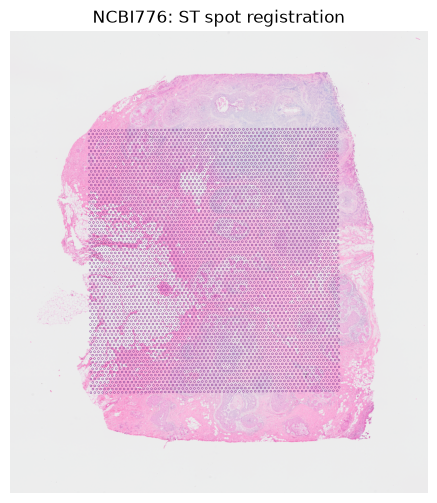

In [5]:
thumbnail = wsi.get_thumbnail(size=1000, as_array=True)
slide_height, slide_width = wsi.properties.shape
thumb_height, thumb_width = thumbnail.shape[:2]

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(thumbnail)
ax.scatter(
    spot_xy[:, 0] * thumb_width / slide_width,
    spot_xy[:, 1] * thumb_height / slide_height,
    s=2,
    facecolors="none",
    edgecolors="#873D95",
    linewidths=0.3,
    marker="h",
)
ax.set(title=f"{SAMPLE_ID}: ST spot registration")
ax.axis("off")
plt.show()

## Normalize stains and feature extraction with CTransPath

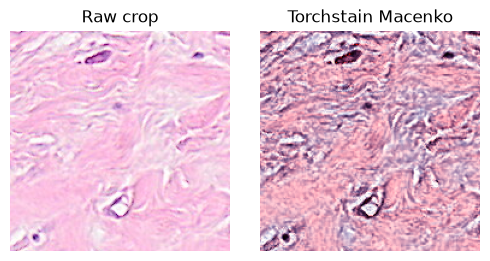

In [6]:
macenko_normalizer = torchstain.normalizers.MacenkoNormalizer(backend="torch")
ctranspath_transform = Compose(
    [
        ToImage(),
        ToDtype(dtype=torch.float32, scale=True),
        Resize(size=(224, 224), antialias=False),
        Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
)


def path2space_macenko(tile, return_rgb=False):
    tile = np.asarray(tile, dtype=np.uint8)
    brightness = np.percentile(tile, 95)
    brightness = max(brightness, 1.0)
    standardized = np.clip(tile.astype(np.float32) * 255.0 / brightness, 0, 255).astype(
        np.uint8
    )
    tensor = torch.from_numpy(standardized.copy()).permute(2, 0, 1)
    try:
        normalized, _, _ = macenko_normalizer.normalize(
            I=tensor, Io=255, alpha=1, beta=0.15, stains=False
        )
        normalized = normalized.clamp(0, 255).to(torch.uint8).cpu().numpy()
    except (IndexError, RuntimeError):
        normalized = standardized
    if return_rgb:
        return normalized
    return ctranspath_transform(normalized)


tile_dataset = wsi.ds.tile_images(tile_key="spots")
preview_index = len(tile_dataset) // 2
preview_raw = np.asarray(tile_dataset[preview_index]["image"])
preview_normalized = path2space_macenko(preview_raw, return_rgb=True)
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), constrained_layout=True)
for ax, image, title in zip(
    axes,
    [preview_raw, preview_normalized],
    ["Raw crop", "Torchstain Macenko"],
    strict=True,
):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")
plt.show()

In [7]:
zs.tl.feature_extraction(
    wsi,
    "ctranspath",
    tile_key="spots",
    batch_size=64,
    amp=False,
    transform=path2space_macenko,
)

Output()

## Predict expression with Path2Space

`feature_prediction` resolves the Path2Space ensemble and consumes the CTransPath feature table. A small batch limits the ensemble's intermediate memory. Predictions are aligned to HEST barcodes through the tile table rather than by relying on positional reassignment.

In [8]:
zs.tl.feature_prediction(
    wsi,
    "path2space",
    tile_key="spots",
    batch_size=16,
    amp=False,
)
pred_raw = wsi.tables["path2space_spots"].copy()
pred_raw.obs_names = pd.Index(spot_ids, name="spot_id")
prediction_values = np.asarray(pred_raw.X, dtype=np.float32)

Output()

## Apply spatial smoothing

The tiles are converted to integer grid coordinates, a radius-2 KDTree neighborhood is built, and each prediction is replaced by the uniform mean of its neighborhood (including itself).

In [9]:
selected_xy = np.asarray(st[spot_ids].obsm["spatial"], dtype=float)[:, :2]
grid_coordinates = np.column_stack(
    [
        ((selected_xy[:, 0] - selected_xy[:, 0].min()) / SPOT_TILE_PX + 1).astype(int),
        ((selected_xy[:, 1] - selected_xy[:, 1].min()) / SPOT_TILE_PX + 1).astype(int),
    ]
)
neighbors = cKDTree(grid_coordinates).query_ball_point(grid_coordinates, r=2.0)
row_indices = np.repeat(np.arange(len(neighbors)), [len(group) for group in neighbors])
column_indices = np.concatenate(neighbors)
weights = np.concatenate(
    [np.full(len(group), 1 / len(group), dtype=np.float32) for group in neighbors]
)
smoothing_matrix = sparse.csr_matrix(
    (weights, (row_indices, column_indices)),
    shape=(len(neighbors), len(neighbors)),
)

pred_smoothed = pred_raw.copy()
pred_smoothed.X = smoothing_matrix @ prediction_values

## Compare with measured expression

Path2Space outputs are not calibrated to the absolute units of measured counts, so we compare spatial patterns using per-gene Pearson correlation. Constant genes are reported as missing correlations.

In [10]:
common_genes = st.var_names.intersection(pred_raw.var_names, sort=False)
measured = st[spot_ids, common_genes].copy()
pred_raw = pred_raw[spot_ids, common_genes].copy()
pred_smoothed = pred_smoothed[spot_ids, common_genes].copy()

In [11]:
def dense_array(matrix):
    return matrix.toarray() if sparse.issparse(matrix) else np.asarray(matrix)


def per_gene_pearson(measured, predicted, chunk_size=512):
    correlations = []
    for start in range(0, measured.n_vars, chunk_size):
        stop = min(start + chunk_size, measured.n_vars)
        observed = dense_array(measured.X[:, start:stop]).astype(np.float32)
        estimated = dense_array(predicted.X[:, start:stop]).astype(np.float32)
        observed -= observed.mean(axis=0)
        estimated -= estimated.mean(axis=0)
        denominator = np.sqrt((observed**2).sum(axis=0) * (estimated**2).sum(axis=0))
        correlations.append(
            np.divide(
                (observed * estimated).sum(axis=0),
                denominator,
                out=np.full(stop - start, np.nan, dtype=np.float32),
                where=denominator > 0,
            )
        )
    return pd.Series(np.concatenate(correlations), index=measured.var_names)


gene_correlations = pd.DataFrame(
    {
        "raw prediction": per_gene_pearson(measured, pred_raw),
        "smoothed prediction": per_gene_pearson(measured, pred_smoothed),
    }
)
gene_correlations.median().rename("median Pearson correlation")

raw prediction         0.275498
smoothed prediction    0.345017
Name: median Pearson correlation, dtype: float32

In [12]:
gene_correlations.loc[TARGET_GENES]

,raw prediction,smoothed prediction
CHEK2,0.291663,0.332098
ERBB2,0.400178,0.471052
CDH1,0.419189,0.523107


## Spatial maps of breast-cancer genes

Measured counts and predictions use different units, so each map has its own color scale.

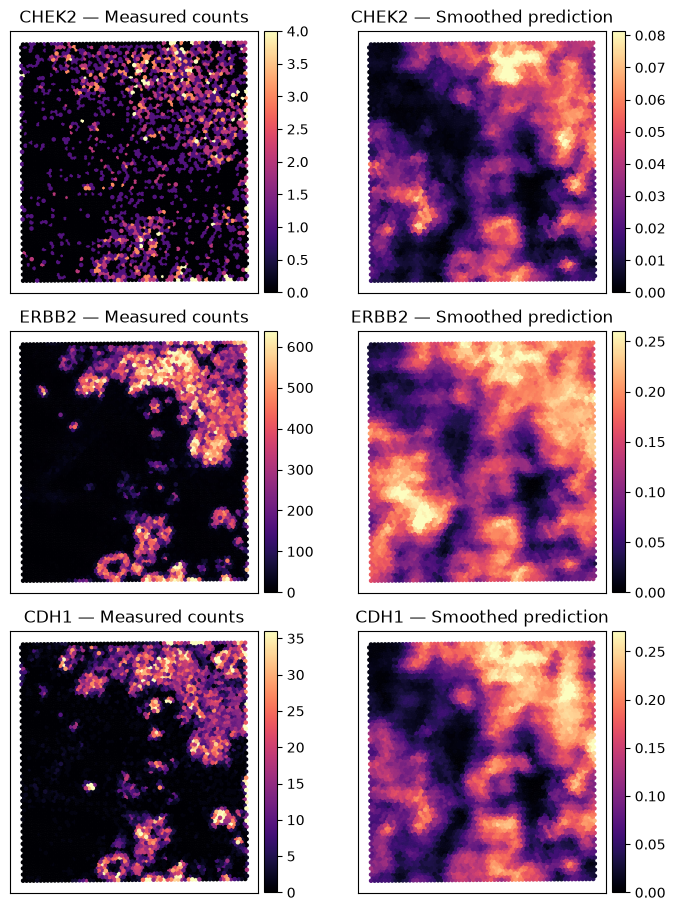

In [13]:
fig, axes = plt.subplots(len(TARGET_GENES), 2, figsize=(7, 9), constrained_layout=True)
for row, gene in enumerate(TARGET_GENES):
    observed = dense_array(measured[:, gene].X).ravel()
    estimated = dense_array(pred_smoothed[:, gene].X).ravel()
    panels = [(observed, "Measured counts"), (estimated, "Smoothed prediction")]
    for ax, (values, title) in zip(axes[row], panels, strict=True):
        artist = ax.scatter(
            selected_xy[:, 0],
            selected_xy[:, 1],
            c=values,
            s=5,
            cmap="magma",
            vmin=0,
            vmax=np.quantile(values, 0.99),
        )
        ax.invert_yaxis()
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{gene} — {title}")
        fig.colorbar(artist, ax=ax, fraction=0.046, pad=0.02)
plt.show()

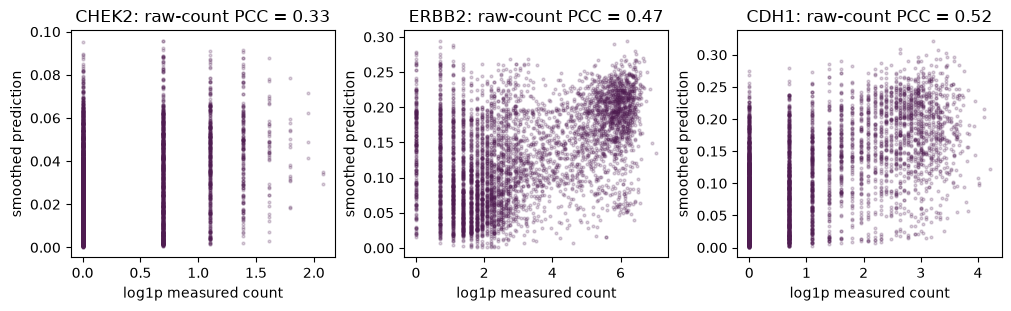

In [14]:
fig, axes = plt.subplots(1, len(TARGET_GENES), figsize=(10, 3), constrained_layout=True)
for ax, gene in zip(axes, TARGET_GENES, strict=True):
    observed = dense_array(measured[:, gene].X).ravel()
    estimated = dense_array(pred_smoothed[:, gene].X).ravel()
    ax.scatter(np.log1p(observed), estimated, s=4, alpha=0.2, color="#4F1C51")
    ax.set(
        title=f"{gene}: raw-count PCC = {gene_correlations.loc[gene, 'smoothed prediction']:.2f}",
        xlabel="log1p measured count",
        ylabel="smoothed prediction",
    )
plt.show()

## Predict expression with DeepSpot-M

[Path2Space](https://doi.org/10.1016/j.cell.2026.04.023) predicts expression from **precomputed CTransPath features** through `tl.feature_prediction`. [DeepSpot-M](https://github.com/ratschlab/DeepSpotM) takes the complementary route: it is a **`tile_prediction`** model that maps each H&E tile to transcriptome-wide expression end-to-end — a LoRA-adapted Midnight backbone with a cross-attention gene decoder — so it runs directly on the spot tiles with `tl.tile_prediction` and needs no separate feature-extraction step. Each crop is resized to 224 px internally.

DeepSpot-M weights are gated and non-commercial: request access on the [model page](https://huggingface.co/ratschlab/DeepSpotM), run `huggingface-cli login`, then install with `pip install git+https://github.com/ratschlab/DeepSpotM.git`.

In [15]:
from lazyslide_models.tile_prediction import DeepSpotM

# DeepSpot-M scores tiles directly — no CTransPath features required.
# Restrict to the marker panel we compare below; pass genes=None for the full ~19k-gene panel.
zs.tl.tile_prediction(wsi, DeepSpotM(genes=TARGET_GENES), tile_key="spots", batch_size=16)

# tile_prediction writes one column per gene onto the spot tile table, in tile order.
# Collect them into an AnnData aligned to the HEST spot barcodes used above.
deepspotm_pred = ad.AnnData(
    X=wsi.shapes["spots"][TARGET_GENES].to_numpy(dtype=np.float32),
    obs=pd.DataFrame(index=pd.Index(spot_ids, name="spot_id")),
    var=pd.DataFrame(index=pd.Index(TARGET_GENES, name="gene")),
)

In [16]:
# Same per-gene Pearson comparison used for Path2Space, on the marker panel.
per_gene_pearson(measured[:, TARGET_GENES].copy(), deepspotm_pred).rename(
    "DeepSpot-M Pearson correlation"
)

CHEK2    0.458160
ERBB2    0.776366
CDH1     0.740558
Name: DeepSpot-M Pearson correlation, dtype: float32

## Conclusions

This workflow uses spot-centred crops, Macenko stain normalization, CTransPath features, and Path2Space prediction. Spatial smoothing improves agreement with measured expression for this example, while independently scaled maps avoid implying that predicted values are calibrated molecular counts.

This remains a single-slide demonstration and is not intended for clinical use.